# 05 — Preprocesado: contrastes de hipótesis y selección de variables

TFM — Emisiones de CO₂ de los vehículos nuevos matriculados en la UE.

Parte del conjunto ya depurado por `src/02_preprocesado.py`, que aplicó las
decisiones D-08 a D-16 y conservó 1.072.129 de los 1.076.533 registros.

Objetivo: descartar las variables que no pueden entrar en el modelo, contrastar
estadísticamente las diferencias entre combustibles, resolver la
multicolinealidad y construir las variables derivadas. Alimenta los apartados
4.4 y 4.5 de la memoria.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

import estilo
estilo.aplicar()

RAIZ = Path.cwd().parent
LIMPIO = RAIZ / "datos" / "procesado" / "co2cars_2024_limpio.parquet"

EWLTP  = "Ewltp (g/km)"
MASA   = "M (kg)"
MASA_T = "Mt"
CILIND = "Ec (cm3)"
POTEN  = "Ep (KW)"
ERWLTP = "Erwltp (g/km)"


def es(n, dec=0):
    """Formato numérico español: punto de millar y coma decimal."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "·").replace(".", ",").replace("·", ".")


df = pd.read_parquet(LIMPIO)

# El modelo principal se ajusta sobre la combustión. Los enchufables se
# reservan para el contraste empírico de la decisión de segmentar.
comb = df[df["regimen"] == "Combustión"].copy()

print(f"Conjunto depurado: {es(len(df))} registros")
print(df["regimen"].value_counts().to_string())

Conjunto depurado: 1.072.129 registros
regimen
Combustión            839684
Cero emisiones        155728
Híbrido enchufable     76717


## 1. Fuga de información: el consumo no puede ser predictor

El consumo declarado y las emisiones proceden del mismo ensayo de homologación
y están ligados por la estequiometría de la combustión. Antes de usarlo como
variable explicativa hay que medir hasta qué punto lo determina.

In [2]:
filas = []
for f, g in comb.groupby("ft_norm"):
    g = g.dropna(subset=["Fc", EWLTP])
    if len(g) > 1000:
        r = g[["Fc", EWLTP]].corr().iloc[0, 1]
        filas.append({"combustible": f, "n": len(g), "r": round(r, 4),
                      "R2": round(r ** 2, 4)})

fuga = pd.DataFrame(filas).sort_values("n", ascending=False)
print("Correlación entre consumo y emisiones DENTRO de cada combustible:")
print(fuga.to_string(index=False))
print("\nEl consumo explica por sí solo entre el 65 % y el 98 % de la variable")
print("objetivo según el combustible. Se excluye del conjunto de predictores.")

Correlación entre consumo y emisiones DENTRO de cada combustible:
combustible      n      r     R2
     petrol 639262 0.9772 0.9548
     diesel 159377 0.9834 0.9670
        lpg  32094 0.8038 0.6461
        e85   2752 0.9900 0.9800

El consumo explica por sí solo entre el 65 % y el 98 % de la variable
objetivo según el combustible. Se excluye del conjunto de predictores.


## 2. Multicolinealidad entre los predictores físicos

El factor de inflación de la varianza mide cuánto se infla la varianza del
coeficiente de una variable por su correlación con las demás. Valores por
encima de 10 se consideran problemáticos porque hacen inestable la estimación.

In [3]:
def vif(tabla, columnas, muestra=200_000, semilla=42):
    X = tabla[columnas].dropna()
    if len(X) > muestra:
        X = X.sample(muestra, random_state=semilla)
    Xc = X.assign(const=1.0)
    return pd.DataFrame({"variable": columnas,
                         "VIF": [round(variance_inflation_factor(Xc.values, i), 2)
                                 for i in range(len(columnas))]})


print("Con ambas medidas de masa:")
print(vif(comb, [MASA, MASA_T, CILIND, POTEN]).to_string(index=False))

print("\nTras eliminar la masa de ensayo:")
print(vif(comb, [MASA, CILIND, POTEN]).to_string(index=False))

r_masas = comb[[MASA, MASA_T]].corr().iloc[0, 1]
print(f"\nCorrelación entre las dos medidas de masa: r = {r_masas:.4f}")

Con ambas medidas de masa:
variable   VIF
  M (kg) 68.35
      Mt 65.48
Ec (cm3)  3.59
 Ep (KW)  2.87

Tras eliminar la masa de ensayo:


variable  VIF
  M (kg) 2.59
Ec (cm3) 3.58
 Ep (KW) 2.87

Correlación entre las dos medidas de masa: r = 0.9922


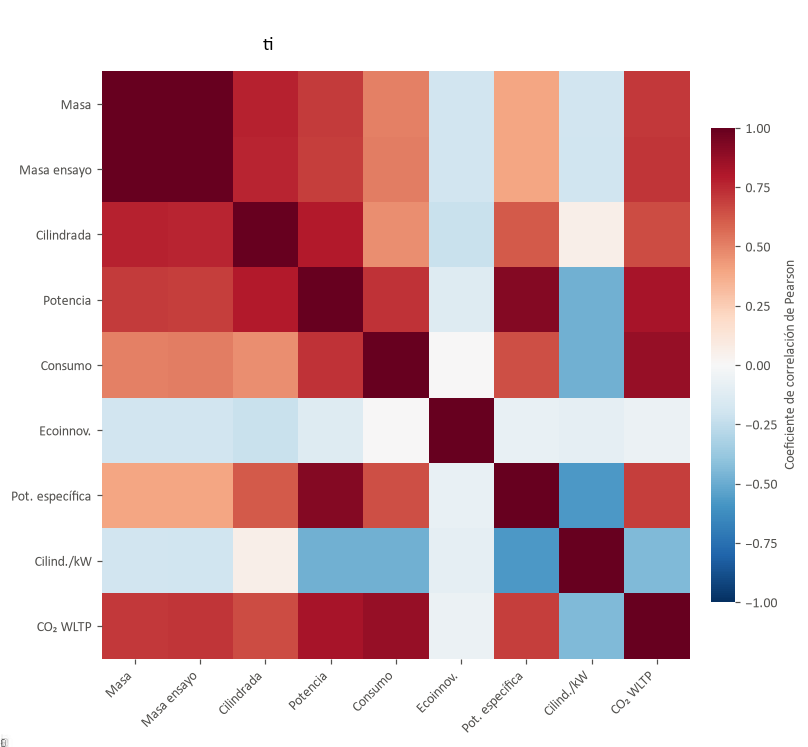

In [4]:
# Variables derivadas. La potencia específica normaliza la potencia por el peso
# que debe mover; la cilindrada por kilovatio es un indicador inverso del grado
# de sobrealimentación, y separa motores atmosféricos de turboalimentados.
comb["pot_especifica"] = comb[POTEN] / comb[MASA] * 1000     # W por kg
comb["cil_por_kw"] = comb[CILIND] / comb[POTEN]              # cm³ por kW
comb["tiene_ecoinnov"] = (comb[ERWLTP] > 0).astype(int)

COLS = [MASA, MASA_T, CILIND, POTEN, "Fc", ERWLTP,
        "pot_especifica", "cil_por_kw", EWLTP]
ETIQUETAS = ["Masa", "Masa ensayo", "Cilindrada", "Potencia", "Consumo",
             "Ecoinnov.", "Pot. específica", "Cilind./kW", "CO₂ WLTP"]
m = comb[COLS].corr()

fig, ax = plt.subplots(figsize=(8.4, 7))
im = ax.imshow(m.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(COLS)))
ax.set_xticklabels(ETIQUETAS, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(COLS)))
ax.set_yticklabels(ETIQUETAS, fontsize=9)
for i in range(len(COLS)):
    for j in range(len(COLS)):
        v = m.values[i, j]
        ax.text(j, i, f"{v:.2f}".replace(".", ","), ha="center", va="center",
                fontsize=8.5, color="white" if abs(v) > 0.55 else "#0b0b0b")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.03)
cb.outline.set_visible(False)
cb.set_label("Coeficiente de correlación de Pearson", fontsize=9)
ax.set_title("Correlaciones entre variables numéricas\n"
             "Vehículos de combustión, UE 2024", fontsize=12.5, pad=14, loc="left")
fig.savefig(estilo.DIR_FIGURAS / "fig_07_correlaciones.png")
plt.show()

In [5]:
# Las variables derivadas también deben superar el contraste de colinealidad:
# la potencia específica se construye a partir de la potencia y podría duplicarla.
print("Predictores físicos más derivadas:")
print(vif(comb, [MASA, CILIND, POTEN, "pot_especifica", "cil_por_kw"])
      .to_string(index=False))

Predictores físicos más derivadas:


      variable   VIF
        M (kg) 11.76
      Ec (cm3) 13.37
       Ep (KW) 43.42
pot_especifica 32.26
    cil_por_kw  5.79


## 3. Contraste de diferencias entre combustibles

Con más de ochocientos mil registros, cualquier diferencia por pequeña que sea
resulta estadísticamente significativa. El valor p pierde por tanto capacidad
para discriminar lo relevante, y la conclusión debe apoyarse en el tamaño del
efecto.

In [6]:
grupos = {f: g[EWLTP].dropna().values
          for f, g in comb.groupby("ft_norm") if len(g) > 1000}
print("Grupos contrastados:", {k: len(v) for k, v in grupos.items()})

# Levene sobre la mediana: comprueba si las varianzas son homogéneas, que es
# el supuesto que exige el ANOVA clásico.
W, p_lev = stats.levene(*grupos.values(), center="median")
print(f"\nLevene        W = {W:12,.1f}   p = {p_lev:.3g}")

# Kruskal-Wallis no exige normalidad ni homocedasticidad
H, p_kw = stats.kruskal(*grupos.values())
N = sum(len(v) for v in grupos.values())
k = len(grupos)
epsilon2 = (H - k + 1) / (N - k)
print(f"Kruskal-Wallis H = {H:12,.1f}   p = {p_kw:.3g}   ε² = {epsilon2:.4f}")

F, p_anova = stats.f_oneway(*grupos.values())
todos = np.concatenate(list(grupos.values()))
media = todos.mean()
ss_entre = sum(len(v) * (v.mean() - media) ** 2 for v in grupos.values())
eta2 = ss_entre / ((todos - media) ** 2).sum()
print(f"ANOVA          F = {F:12,.1f}   p = {p_anova:.3g}   η² = {eta2:.4f}")

print(f"\nEl tipo de combustible explica el {100 * epsilon2:.1f} % de la")
print("variabilidad de las emisiones dentro de los vehículos de combustión.")

Grupos contrastados: {'diesel': 161543, 'e85': 2752, 'lpg': 32195, 'petrol': 642892}

Levene        W =      3,586.9   p = 0
Kruskal-Wallis H =    100,405.8   p = 0   ε² = 0.1196
ANOVA          F =     24,161.5   p = 0   η² = 0.0795

El tipo de combustible explica el 12.0 % de la
variabilidad de las emisiones dentro de los vehículos de combustión.


## 4. Gasolina frente a gasóleo

El contraste entre los dos combustibles mayoritarios se examina por separado
porque concentra el 96 % de los vehículos de combustión y porque el resultado
es contraintuitivo: el motor diésel es termodinámicamente más eficiente.

In [7]:
a, b = grupos["petrol"], grupos["diesel"]
t, p_t = stats.ttest_ind(a, b, equal_var=False)      # Welch, sin suponer varianzas iguales
s = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
            / (len(a) + len(b) - 2))
d = (b.mean() - a.mean()) / s

print(f"gasolina   n = {es(len(a)):>9}   media = {a.mean():6.2f}   sd = {a.std():5.2f}")
print(f"gasóleo    n = {es(len(b)):>9}   media = {b.mean():6.2f}   sd = {b.std():5.2f}")
print(f"\nWelch      t = {t:,.1f}   p = {p_t:.3g}")
print(f"Diferencia   = {b.mean() - a.mean():.2f} g/km")
print(f"d de Cohen   = {d:.3f}")

gasolina   n =   642.892   media = 130.62   sd = 27.55
gasóleo    n =   161.543   media = 149.63   sd = 29.24

Welch      t = -236.2   p = 0
Diferencia   = 19.01 g/km
d de Cohen   = 0.681


## 5. Conjunto final de variables

Se guarda la tabla lista para el modelado con las variables que han superado
los tres filtros: no introducen fuga de información, no presentan
multicolinealidad problemática y aportan señal sobre el objetivo.

In [8]:
NUMERICAS = [MASA, CILIND, POTEN, ERWLTP, "cil_por_kw", "tiene_ecoinnov"]
CATEGORICAS = ["ft_norm", "Fm", "marca_norm", "MS", "Mp"]

print("Correlación de cada candidata con la variable objetivo:")
print(comb[NUMERICAS + ["pot_especifica", "Fc", MASA_T, EWLTP]]
      .corr()[EWLTP].drop(EWLTP)
      .sort_values(key=abs, ascending=False).round(3).to_string())

modelado = comb[NUMERICAS + CATEGORICAS + [EWLTP, "regimen", "ep_no_fiable"]].copy()
destino = RAIZ / "datos" / "procesado" / "modelado_combustion.parquet"
modelado.to_parquet(destino, index=False, compression="snappy")

print(f"\nGuardado: {destino.name}")
print(f"{es(len(modelado))} filas x {len(modelado.columns)} columnas")
print(f"Numéricas:   {NUMERICAS}")
print(f"Categóricas: {CATEGORICAS}")

Correlación de cada candidata con la variable objetivo:


Fc                0.874
Ep (KW)           0.824
Mt                0.718
M (kg)            0.703
pot_especifica    0.693
Ec (cm3)          0.650
cil_por_kw       -0.441
tiene_ecoinnov   -0.148
Erwltp (g/km)    -0.056



Guardado: modelado_combustion.parquet
839.684 filas x 14 columnas
Numéricas:   ['M (kg)', 'Ec (cm3)', 'Ep (KW)', 'Erwltp (g/km)', 'cil_por_kw', 'tiene_ecoinnov']
Categóricas: ['ft_norm', 'Fm', 'marca_norm', 'MS', 'Mp']
